#I. Data set description

| Variable | Type | Description | Units |
|:---------|:-----|:------------|:------|
| `id_lab` | Character | Laboratory sample identifier | — |
| `id` | Character | Germplasm accession identifier | — |
| `subset` | Integer | Experimental subset identifier | — |
| `no` | Numeric | Sample number | — |
| `requisitioner` | Character | Source or requesting program of the accession | — |
| `tax_name` | Character | Scientific (taxonomic) name of the species | — |
| `functional_group` | Character | Functional group classification | — |
| `n_replicates_nutrition` | Integer | Number of replicates used for nutritional analyses | Replicates |
| `dm_percentage` | Numeric | Dry matter (DM) content | % |
| `ash_dm` | Numeric | Ash content on a dry matter basis | % DM |
| `om_percentage` | Numeric | Organic matter content | % |
| `pc_percentage_dm` | Numeric | Crude protein (CP) content on a dry matter basis | % DM |
| `adf_percentage_dm` | Numeric | Acid detergent fiber (ADF) content on a dry matter basis | % DM |
| `ndf_percentage_dm` | Numeric | Neutral detergent fiber (NDF) content on a dry matter basis | % DM |
| `n_replicates_gas` | Integer | Number of replicates used for gas production measurements | Replicates |
| `ch4_percentage_in_gas_8h` | Numeric | Methane concentration in fermentation gas after 8 h of incubation | % |
| `ch4_percentage_in_gas_24h` | Numeric | Methane concentration in fermentation gas after 24 h of incubation | % |
| `methane_intensity` | Numeric | Methane intensity measured during fermentation | *(units depend on calculation protocol)* |
| `tddm` | Numeric | True dry matter digestibility (TDDM) | % |

# 1.0 Install packages and import libraries

In [ ]:
install.packages("patchwork")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [56]:
library(dplyr)
library(patchwork)

# 2.0 Data load

In [ ]:
url <- "https://raw.githubusercontent.com/maurope/lmf/main/output/2026_05_22_data_delivery/08_dashboard_june_2026/compiled_dashboard_2026_7_10.csv"
df <- read.csv(url)

In [ ]:
#Remove unofficial functional groups
df <- df %>%
  filter(!functional_group %in% c("Concentrate", "Forage", ""))

In [ ]:
head(df)

,id_lab,id,subset,no,requisitioner,tax_name,functional_group,n_replicates_nutrition,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm,n_replicates_gas,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,F24-3470,CIAT-11194,1,199,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,92.89,9.61,90.39,21.18,30.18,55.94,6,15.17,18.02,46.12,59.25
2,F24-3471,CIAT-11999,1,201,Genetic_bank,Stylosanthes guianensis,Herbaceous_legumes,2,93.50,10.46,89.54,20.09,33.90,61.32,9,12.98,16.25,46.61,58.55
3,F24-3472,CIAT-12318,1,203,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,94.10,11.08,88.92,22.05,29.34,55.26,9,13.99,16.96,52.27,56.88
4,F24-3427,CIAT-1257,1,113,Genetic_bank,Stylosanthes scabra,Herbaceous_legumes,2,92.72,9.52,90.48,17.96,35.90,69.91,9,15.71,17.60,46.32,58.95
5,F24-3473,CIAT-13575,1,205,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,94.14,11.52,88.48,23.17,44.09,57.61,9,13.60,16.23,42.43,42.85
6,F24-3474,CIAT-13609,1,207,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,93.40,11.58,88.42,20.01,40.85,58.78,9,13.66,16.31,46.39,38.40


# 3.0 Descriptive stats

## 3.1 Stats by functional group

In [ ]:
df %>%
  group_by(functional_group) %>%
  summarise(
    n = n(),
    dm_percentage = mean(dm_percentage, na.rm = TRUE),
    ash_dm = mean(ash_dm, na.rm = TRUE),
    om_percentage = mean(om_percentage, na.rm = TRUE),
    adf_percentage_dm = mean(adf_percentage_dm, na.rm = TRUE),
    ndf_percentage_dm = mean(ndf_percentage_dm, na.rm = TRUE),
    ch4_percentage_in_gas_8h = mean(ch4_percentage_in_gas_8h, na.rm = TRUE),
    ch4_percentage_in_gas_24h = mean(ch4_percentage_in_gas_24h, na.rm = TRUE),
    methane_intensity = mean(methane_intensity, na.rm = TRUE),
    tddm = mean(tddm, na.rm = TRUE),

  )

functional_group,n,dm_percentage,ash_dm,om_percentage,adf_percentage_dm,ndf_percentage_dm,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Grass,193,95.65233,13.23109,86.76886,30.33710,65.42212,13.68246,14.94429,51.61974,48.45246
Herbaceous_legumes,308,92.78344,11.54951,88.45045,30.27140,53.85140,13.69440,15.37560,49.89394,49.79033
Shrub_Trees,153,93.73222,10.07686,89.92294,35.31464,55.16608,13.70127,15.09940,48.57113,41.95287


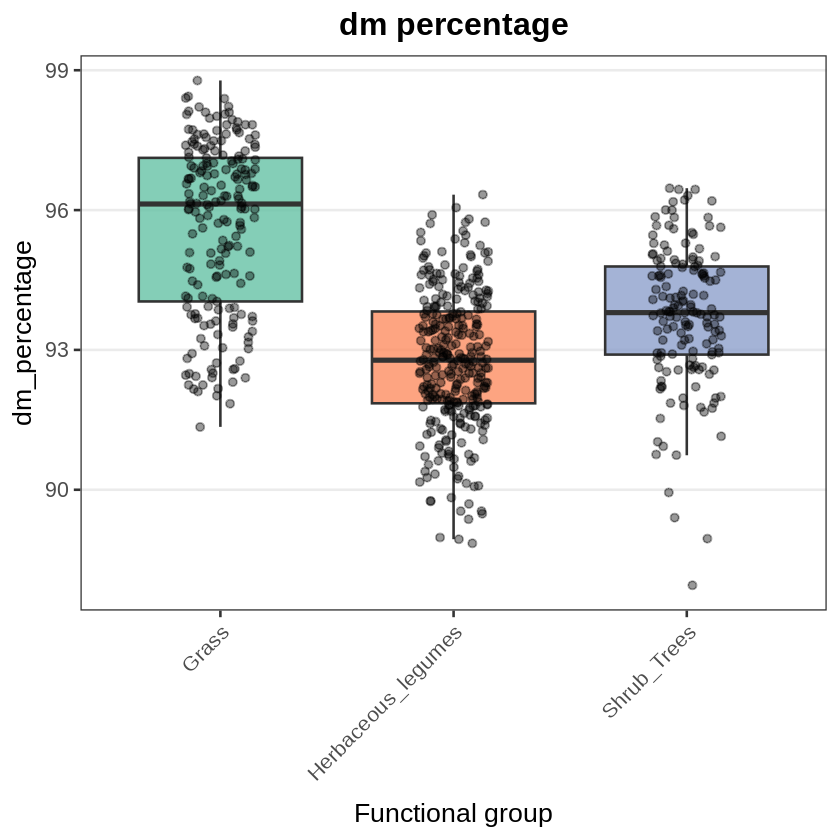

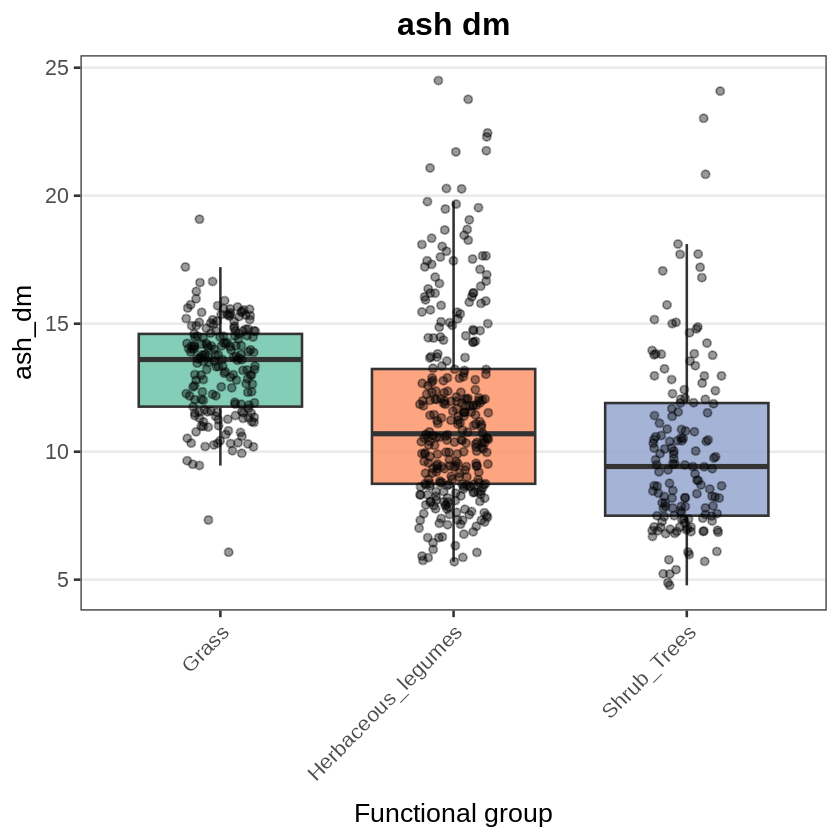

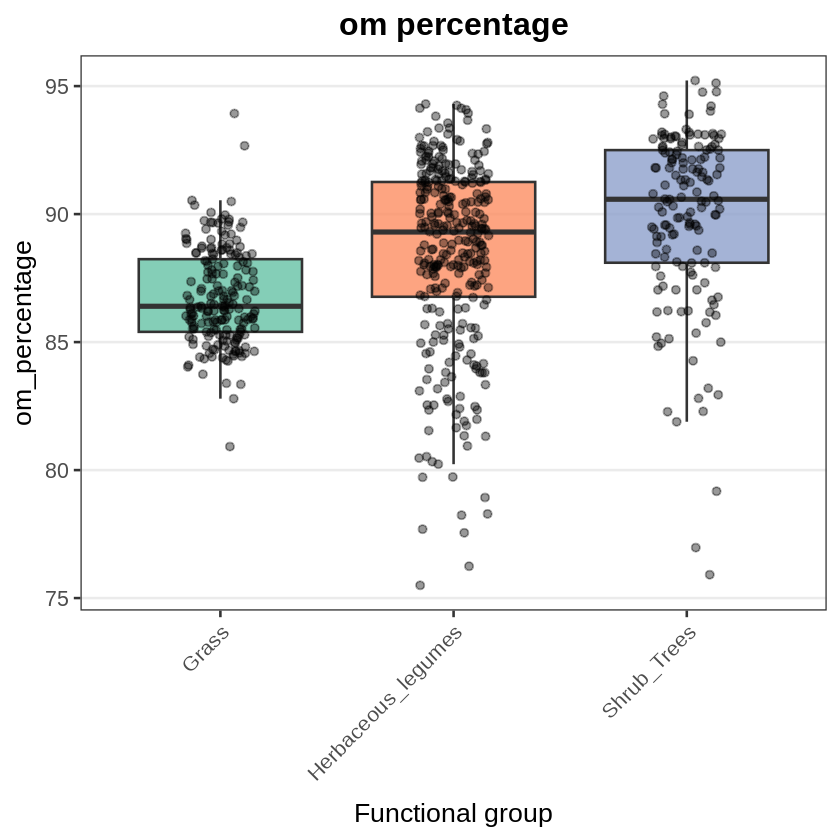

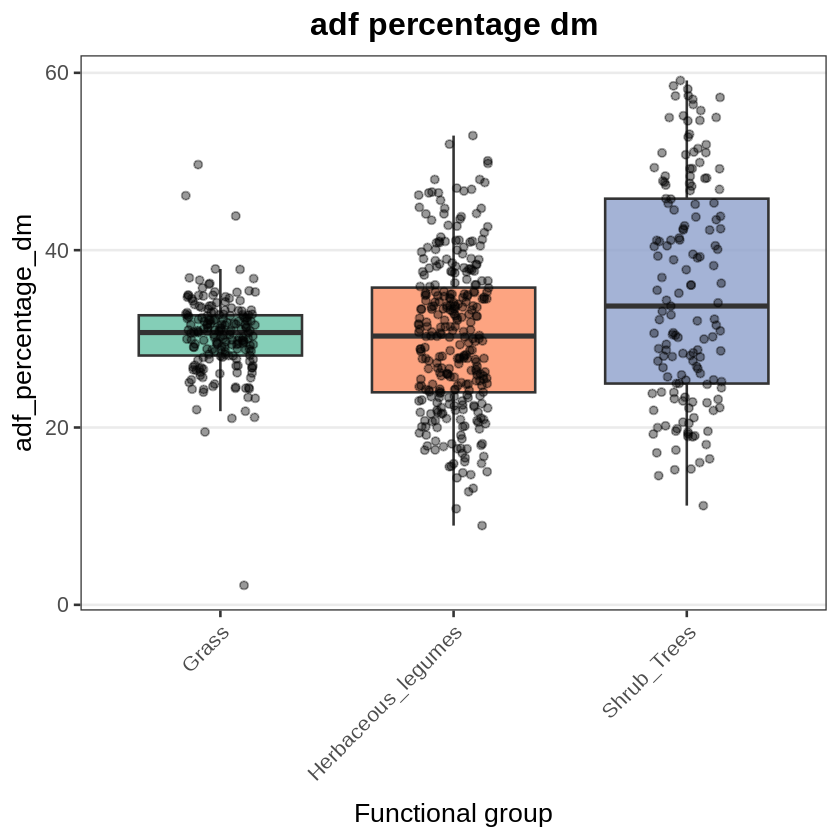

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


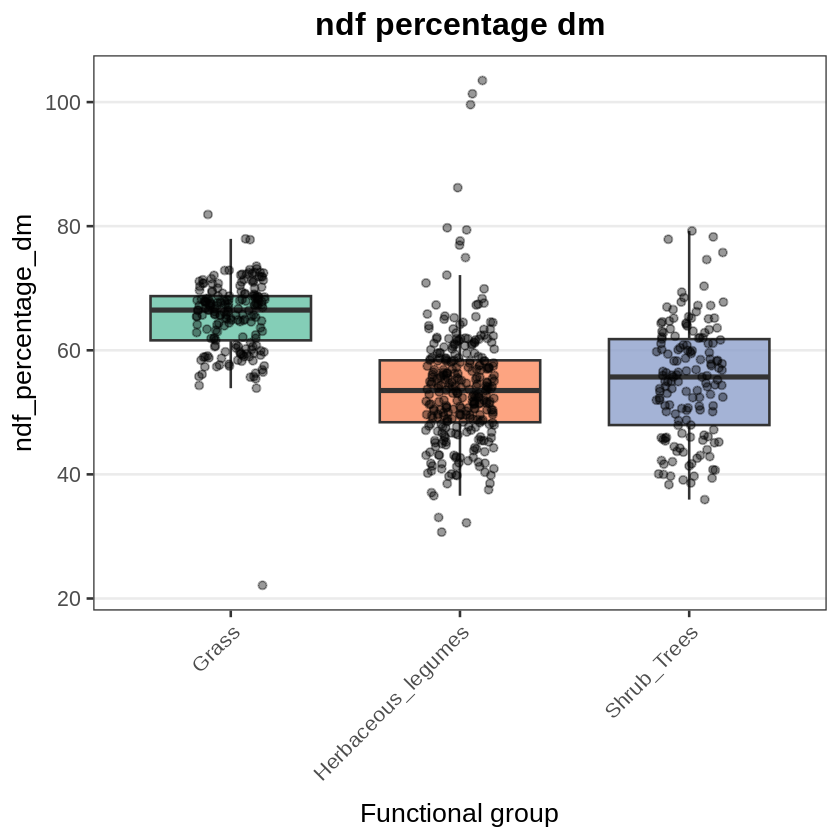

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


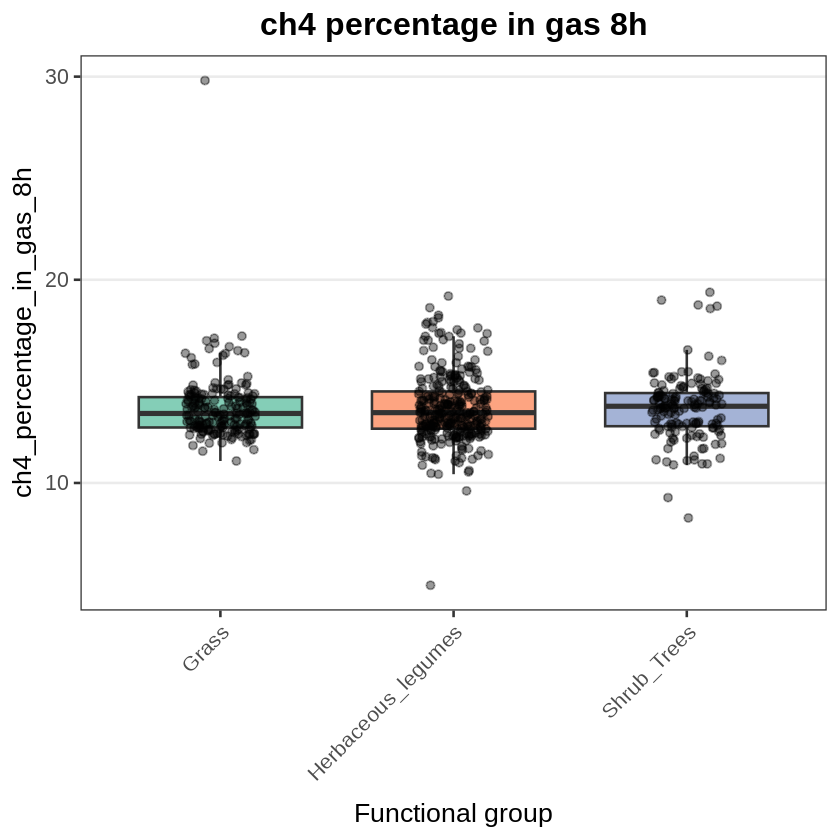

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


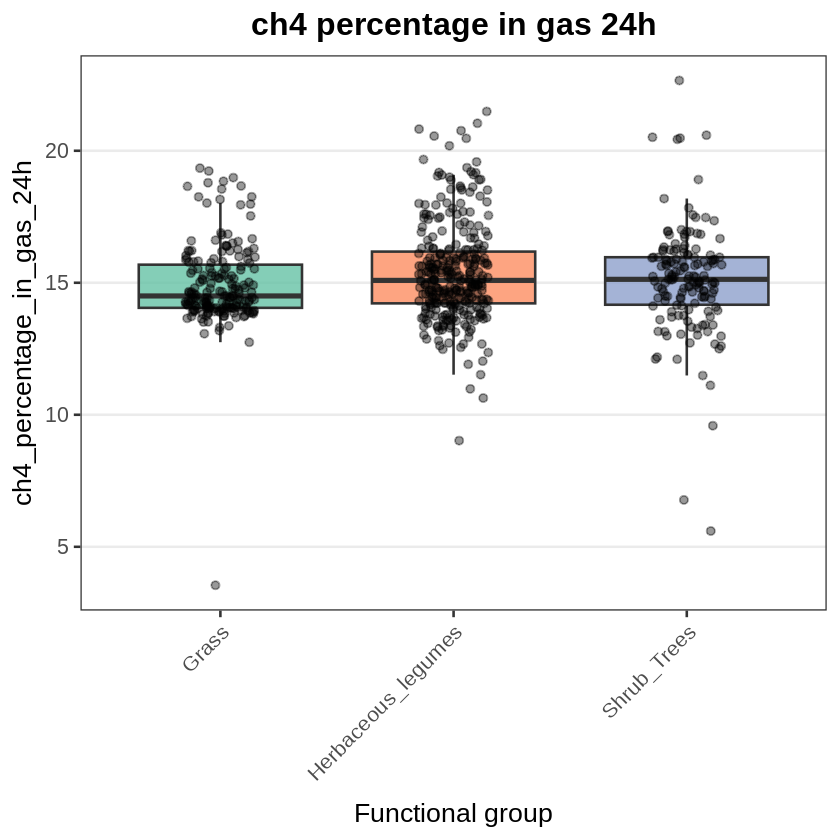

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


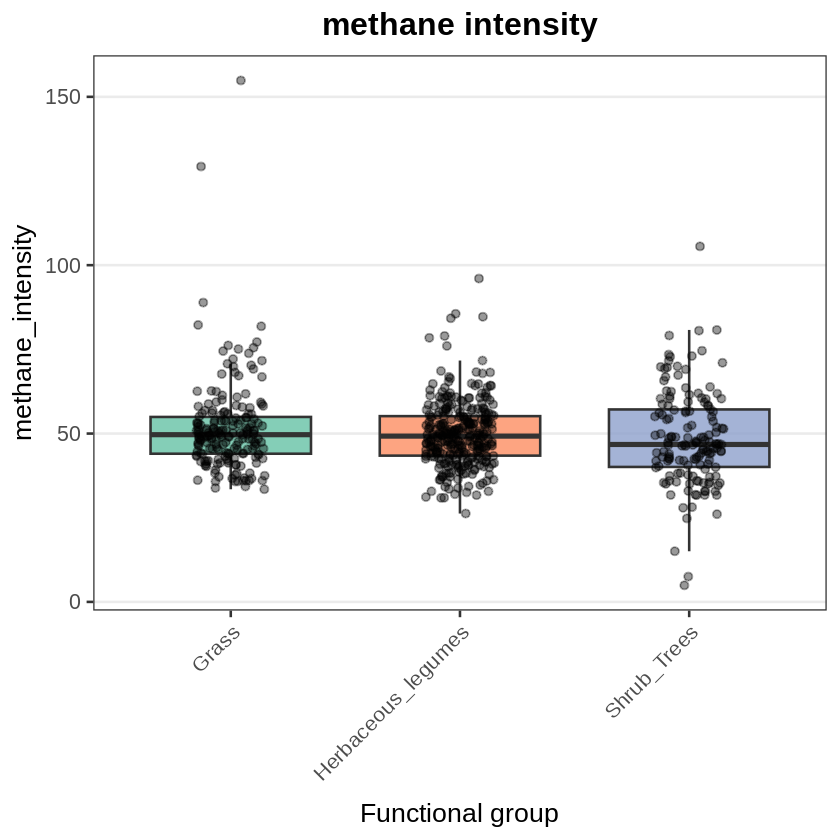

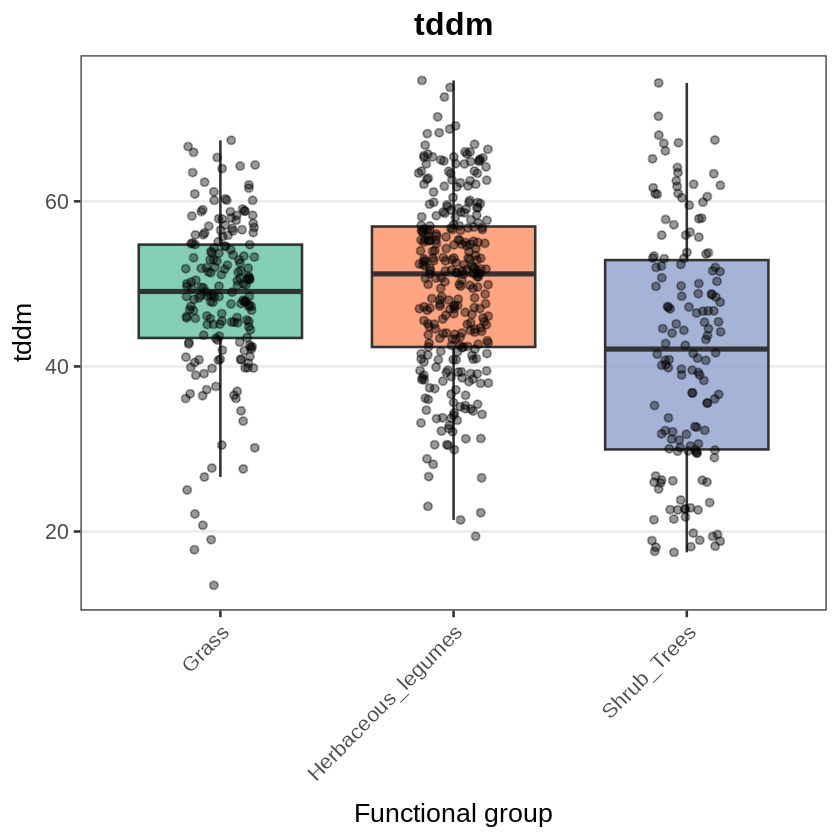

In [ ]:
library(ggplot2)

vars <- c(
  "dm_percentage",
  "ash_dm",
  "om_percentage",
  "adf_percentage_dm",
  "ndf_percentage_dm",
  "ch4_percentage_in_gas_8h",
  "ch4_percentage_in_gas_24h",
  "methane_intensity",
  "tddm"
)

for (v in vars) {

  p <- ggplot(df, aes(x = functional_group,
                      y = .data[[v]],
                      fill = functional_group)) +
    geom_boxplot(width = 0.7, alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.15, alpha = 0.4, size = 1.8) +
    scale_fill_brewer(palette = "Set2") +
    labs(
      x = "Functional group",
      y = v,
      title = gsub("_", " ", v)
    ) +
    theme_bw(base_size = 16) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold", hjust = 0.5),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )

  print(p)
}